# Open-Source SAR ADC Modeling and Prototyping

April 2026

SPDX-License-Identifier: Apache License Version 2.0

<br>

**Team members**

|Name|Affiliation|IEEE Member|SSCS Member|
|:--:|:----------:|:----------:|:----------:|
| Alan Gurlaskie (**Team lead**) <br /> Email: alangurlaskie@ufl.edu | University of Florida (USA) | Yes | Yes |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import subprocess
plt.rcParams['figure.figsize'] = [10, 6]
try:
    import tomllib
except ImportError:
    import tomli as tomllib

## Introduction

* who am i?

    * my name is Alan
 
    * Master's student studying Analog/Mixed-Signal IC Design at the University of Florida
 
    * tasked with designing a SAR ADC for course project - decided to use open-source tools to perform system modeling and discovered their utility in modeling/understanding circuit trade-offs and evaluating designs described in the literature
 
* what is the purpose of this notebook?

    * show the potential of open-source dynamical system modeling tools to perform high-level simulation of analog/mixed-signal circuits
 
    * walk through a sample SAR ADC model implementation and run simuations to explore several common sources of error in SAR ADCs including
 
        * Capacitor Mismatch
        * Comparator Noise
        * CDAC Settling Error

    * use the SAR ADC model to quickly explore the viability of a published capacitor mismatch background calibration scheme

        * since we can choose which effects to include in the model and which to ignore, rapid evaluation of many potential design architectures can be performed (based on time constraints, only one calibration scheme is evaluated in this notebook - offset double conversion background calibration)

* why is this notebook useful for people designing open-source silicon

    * Shows benefits of using existing open-source tools to model analog/mixed-signal circuits

        * Prevents designers from reinventing the wheel by rolling their own simulation code
        * Limits amount of modeling code required making models more accesssible/readable
            * SAR ADC model in this notebook is ~200 LOC
            * Implementation of Offset Double Conversation Controller is another ~100 LOC
        * Gives designers basic insights into the circuit limitations with minimal design effort
        * Provides potential interface to Generative AI tools to understand circuit behavior (most Gen AI contexts include python interpreter)

    * Provides base SAR ADC model that others could potentially use to perform system-level design of open source ADCs 

## What is PathSim?

* dynamical system simulator written by Milan Rother
    * [github](https://github.com/pathsim)
    * [docs](https://docs.pathsim.org/pathsim/v0.19.0/)
* allows users to assemble complex systems and track their state over time under arbitrary initial conditions/inputs
    * Supports modeling of continuous-time and discrete-time dynamics (perfect for mixed-signal circuits!)
* companion browser-based block diagram interface ([PathView](https://view.pathsim.org/)) or local python execution environment
    * due to time constraints, only the script-based simulation flow was explored 

## Basic SAR Modeling and Simulation in PathSim

### Typical Charge-Redistribution SAR ADC Implementation 

* Block diagram for 3-bit top-plate sampling SAR with naive switching algorithm
* "Time trellis" decision tree 
* Description of weights used to generate output code and estimate of output voltage

### Basic CRSAR PathSim Model Simulations

#### CRSAR Interface/Implementation

What is I/O?

Flowchart/event handling process description

#### Single Conversion - 3-bit SAR ADC

* Single conversion with no error sources for 3-bit ADC

In [2]:
!python ./src/single_conv_3b_sim.py -o ./data/single_conv_3b.csv > /dev/null

In [3]:
!cat ./src/single_conv_3b_sim.py

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from pathsim.blocks.sources import Source
from pathsim.blocks.scope import Scope  
from pathsim.connection import Connection
from pathsim.simulation import Simulation
from pathsim.solvers import RKBS32
from crsar import CRSAR
import argparse

parser = argparse.ArgumentParser(description="Accept n and output file path")

parser.add_argument("-o", type=str, required=True, help="Output file path")
parser.add_argument("-se", type=float, required=False, default=0, help="CDAC Settling Error in %")
parser.add_argument("-wa", type=str, required=False, default=None, help="Path to actual conversion weights (assumed to be in npy file)")

args = parser.parse_args()

output_path = args.o
se = args.se
weights_actual = np.load(args.wa) if args.wa is not None else None

n_bits = 3
f_clk = 20e6
T_clk = 1.0 / f_clk
vd = -0.4
vref = 1
vcm = 0.5
OVERSAMPLING_RATIO = 100

# Blocks that define the system
srcp = Source(lambda t: vcm 

![](./figs/single_conv_3b_sim.png)

#### Dynamic ADC Simulation via Prime Sampling Approach 

* Go over basics of prime sampling and standard ADC simulation methodologies
* Sine wave conversion with no error sources for 4,8,12 bit ADC - show SQNR and SFDR in each case (show SFDR "improvement" as FFT size increased)

In [4]:
!cat ./src/dynamic_sim.py

import numpy as np
from pathsim.blocks.sources import Source
from pathsim.blocks.scope import Scope  
from pathsim.blocks.adder import Adder
from pathsim.connection import Connection
from pathsim.simulation import Simulation
from pathsim.solvers import RKBS32
from crsar import CRSAR
import argparse

parser = argparse.ArgumentParser(description="Accept n and output file path")

parser.add_argument("-n", type=int, required=True, help="ADC resolution")
parser.add_argument("-N", type=int, required=True, help="FFT Size")
parser.add_argument("-M", type=int, required=True, help="Signal Frequency Bin")
parser.add_argument("-o", type=str, required=True, help="Output file path")
parser.add_argument("-wa", type=str, required=False, default=None, help="Path to actual conversion weights (assumed to be in npy file)")
parser.add_argument("-we", type=str, required=False, default=None, help="Path to estimated conversion weights (assumed to be in npy file)")
parser.add_argument("-se", type=float, requir

In [5]:
!python ./src/dynamic_sim.py -n 4 -N 16384 -M 511 -o ./data/ideal_dynamic_sim_4b.csv > /dev/null
!python ./src/dynamic_sim.py -n 8 -N 16384 -M 511 -o ./data/ideal_dynamic_sim_8b.csv > /dev/null
!python ./src/dynamic_sim.py -n 12 -N 16384 -M 511 -o ./data/ideal_dynamic_sim_12b.csv > /dev/null

In [6]:
def compute_dynamic_performance(time_series, f_clk, N, M):
    
    # N point FFT starting at first ADC sample
    window = 'boxcar'
    
    nfft = N
    nperseg = N
    scaling = 'spectrum'
    
    f, csd = signal.csd(time_series, time_series, fs=f_clk, 
                        window=window, nperseg=nperseg, nfft=nfft,
                        scaling=scaling)

    delta=1e-25 # prevent bins with absolutely 0 bins (no divide by 0 in log)
    fft_result  = np.sqrt(np.abs(csd[1:])) + delta
    fft_freq = f[1:]
    fft_signal_bin = M - 1
    fft_normalized = (fft_result * np.sqrt(2)) / (2**(n-1)) 
    
    # compute SNDR and SFDR
    sndr = np.sqrt(fft_result[fft_signal_bin]**2 / \
                   (np.sum(fft_result**2) - fft_result[fft_signal_bin]**2))
    sfdr = fft_result[fft_signal_bin] / \
        np.max(np.delete(fft_result, fft_signal_bin))

    return fft_freq, fft_normalized, sndr, sfdr

In [7]:
def bulk_dynamic_sim_analysis(path_to_df, res, n, N, M, f_clk=20e6, 
                              td_tstart=None, td_tstop=None, fig_title=None,
                             plot_enable=True):
    dataset = np.genfromtxt(df, delimiter=',', skip_header=1)
    
    t = dataset[:, 0]
    vout = dataset[:, 1]
    vin = dataset[:, 2]
    done = dataset[:, 3]
    dout = dataset[:, 4]

    tstart = td_tstart if td_tstart is not None else min(t)
    tstop = td_tstop if td_tstop is not None else max(t)
    idx_start = np.argmin(np.abs(t-tstart))
    idx_stop = np.argmin(np.abs(t-tstop))    

    # find which times done experiences rising edge (convesion results ready)
    transitions = np.where(np.diff(done) == 1)[0] + 1

    # get unique dout samples for FFT analysis
    dout_samp = dout[transitions]

    samples_to_skip = 0
    time_series = dout_samp[samples_to_skip:samples_to_skip+N].astype('float')
    fft_freq, fft_normalized, sndr, sfdr = compute_dynamic_performance(time_series,
                                                                      f_clk, N, M)

    if plot_enable:
        # plot sample time domain waveforms
        fig, axs = plt.subplots(3, 1)
        axs[0].plot(t[idx_start:idx_stop], vin[idx_start:idx_stop], label='Vin (samples)')
        axs[0].plot(t[idx_start:idx_stop], vout[idx_start:idx_stop], label='Vout (samples)')
        axs[0].legend()
        axs[0].set_title(f'{res} SAR - Time Domain I/O')
    
        # plot quantization error
        axs[1].plot(t, vout-vin)
        axs[1].set_title(f'{res} SAR - Time Domain Quantization Error')
        # plot FFT
        axs[2].plot(fft_freq, 20*np.log10(fft_normalized))
        axs[2].set_title(f'{res} SAR - SNDR: {20*np.log10(sndr):.2f} dB, SFDR: {20*np.log10(sfdr):.2f} dB')
        axs[2].set_ylim([-130, 5])
        
        if fig_title is not None:
            fig.suptitle(fig_title, fontsize=16)
        
        fig.tight_layout()    

    return sndr, sfdr

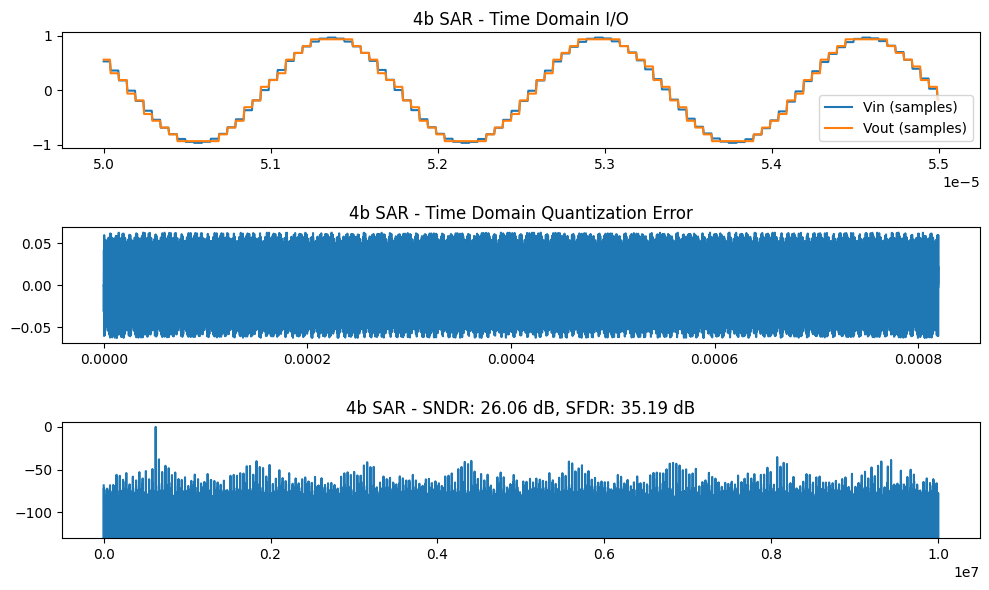

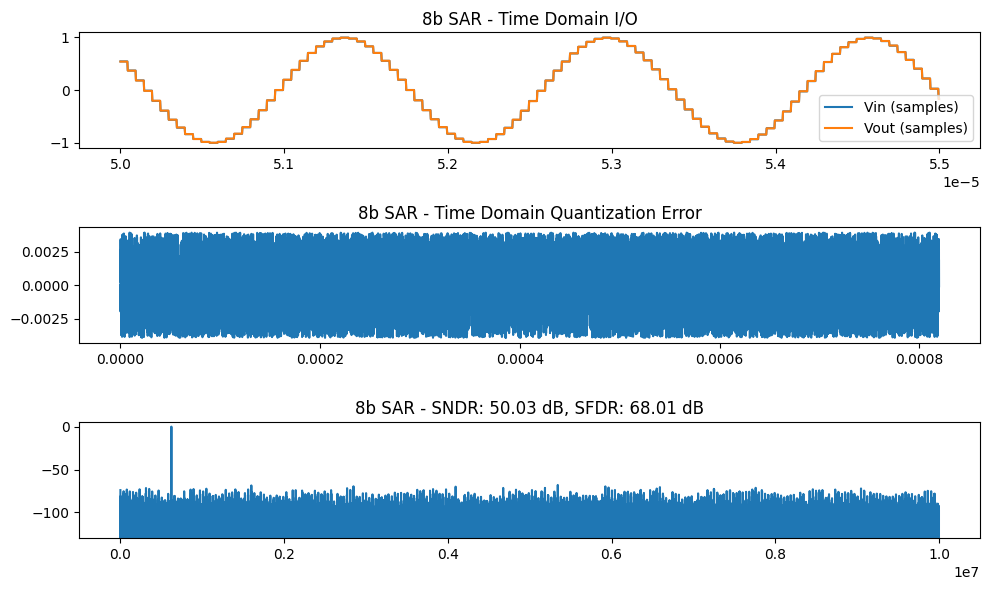

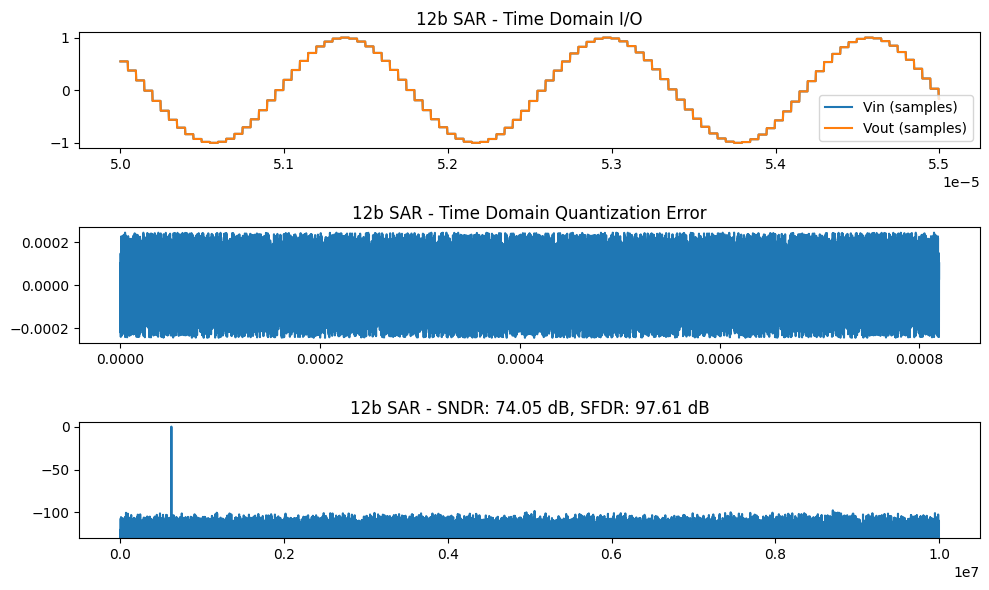

In [8]:
datafiles = ['./data/ideal_dynamic_sim_4b.csv',
            './data/ideal_dynamic_sim_8b.csv',
            './data/ideal_dynamic_sim_12b.csv']

N = 16384
M = 511
f_clk = 20e6

for df in datafiles:
    res = df.rsplit('_', 1)[-1].split('.')[0] # extract number of bits from filename
    nstr, _ = res.split('b')
    n = int(nstr)
    td_tstart = 50e-6
    td_tstop = 55e-6
    bulk_dynamic_sim_analysis(df, res, n, N, M, f_clk, td_tstart, td_tstop)

## Simulating SAR ADC Error Sources

### Capacitor Mismatch

* Flynn paper on mismatch/non-linearity relationship
* Pelgrom Capacitor Matching Model
* Simulation to show SFDR degradation as capacitor mismatch increased

In [9]:
!python ./src/generate_weights.py -n 12 -r 2 -u 1e-14 -s 2e-15 -o ./config > /dev/null

In [10]:
weights_filepaths = [
    './config/weights_estimated_12b_radix2_00.npy',
    './config/weights_actual_12b_radix2_00.npy'
]

for fp in weights_filepaths:
    print(fp)
    print(np.load(fp))
    print('--------------------')

./config/weights_estimated_12b_radix2_00.npy
[5.00000000e-01 2.50000000e-01 1.25000000e-01 6.25000000e-02
 3.12500000e-02 1.56250000e-02 7.81250000e-03 3.90625000e-03
 1.95312500e-03 9.76562500e-04 4.88281250e-04 2.44140625e-04]
--------------------
./config/weights_actual_12b_radix2_00.npy
[4.99711309e-01 2.50755717e-01 1.25101636e-01 6.13527071e-02
 3.16834218e-02 1.57661635e-02 7.64808030e-03 4.01130232e-03
 1.99926472e-03 1.00317382e-03 4.89213678e-04 2.70266447e-04]
--------------------


In [11]:
!python ./src/dynamic_sim.py -n 12 -N 16384 -M 511 -o ./data/capacitor_mismatch_sim.csv \
-wa ./config/weights_actual_12b_radix2_00.npy \
-we ./config/weights_estimated_12b_radix2_00.npy \
> /dev/null

(np.float64(526.3997479023428), np.float64(1267.1912346769045))

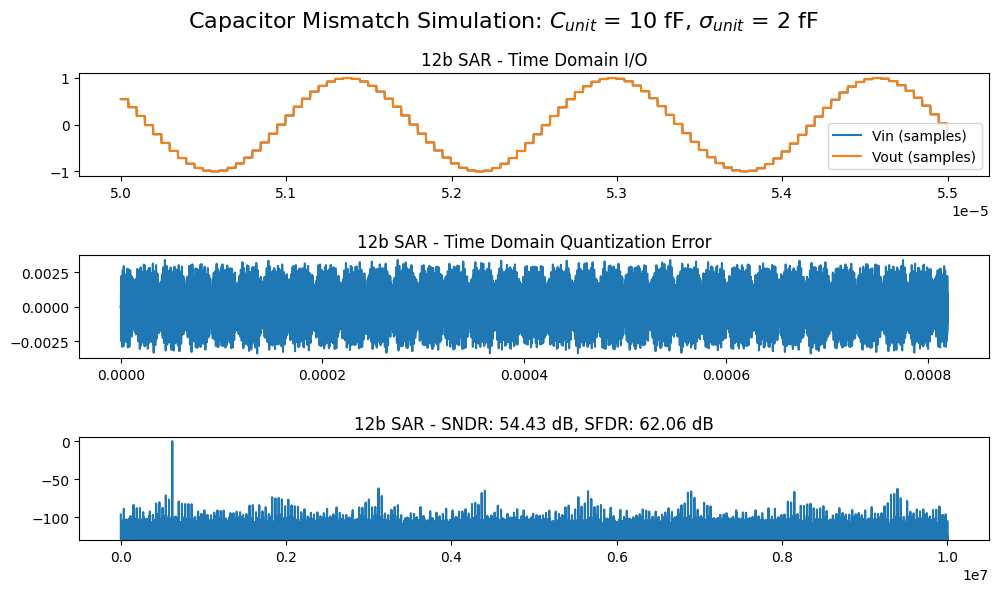

In [12]:
df = './data/capacitor_mismatch_sim.csv'
res = '12b'
n = 12
N = 16384
M = 511
f_clk = 20e6
td_tstart = 50e-6
td_tstop = 55e-6
fig_title = 'Capacitor Mismatch Simulation: $C_{unit}$ = 10 fF, $\sigma_{unit}$ = 2 fF'
bulk_dynamic_sim_analysis(df, res, n, N, M, f_clk, td_tstart, td_tstop, fig_title)

### kT/C Sampling Noise

In [13]:
k = 1.38e-23
T = 300
kTC_noise_rms_total = 1e-3 # 1 mVrms
kTC_noise_rms_se = kTC_noise_rms_total/np.sqrt(2)
C_eq = k*T/(kTC_noise_rms_se**2)
print(C_eq)

8.28e-15


In [14]:
!python ./src/dynamic_sim.py -n 12 -N 16384 -M 511 -sc 8.28e-15 \
-o ./data/kTC_noise_1mVrms_sim.csv > /dev/null

(np.float64(705.8595174714796), np.float64(21407.04372344292))

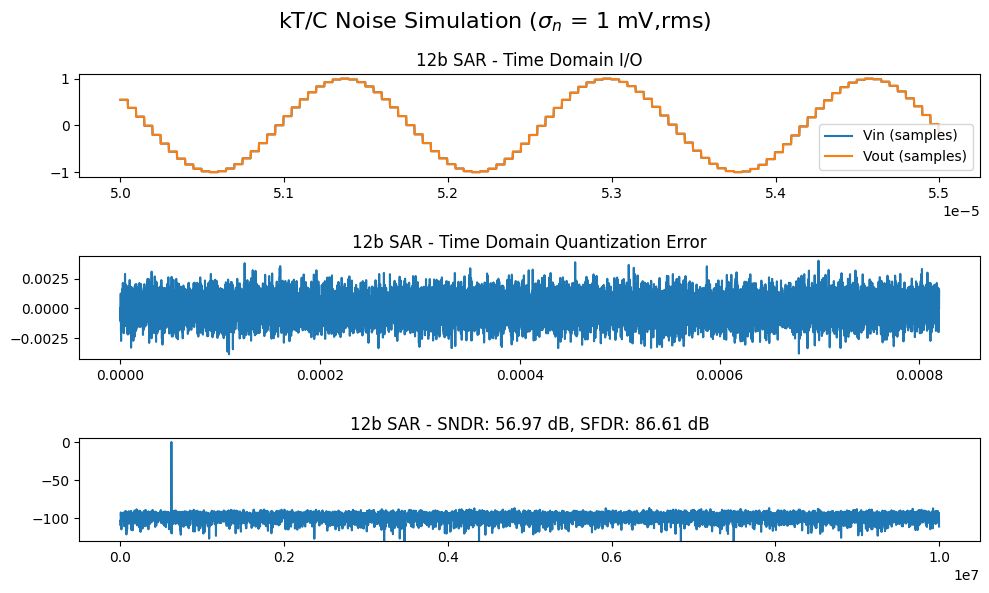

In [15]:
df = './data/kTC_noise_1mVrms_sim.csv'
res = '12b'
n = 12
N = 16384
M = 511
f_clk = 20e6
td_tstart = 50e-6
td_tstop = 55e-6
fig_title = 'kT/C Noise Simulation ($\\sigma_{n}$ = 1 mV,rms)'
bulk_dynamic_sim_analysis(df, res, n, N, M, f_clk, td_tstart, td_tstop, fig_title)

In [16]:
kTC_noise_rms = np.logspace(start=-5, stop=-2, num=30)
kTC_noise_rms_se = kTC_noise_rms/np.sqrt(2)
samp_caps = k*T/(kTC_noise_rms_se**2)
N = 4096
M = 13
n = 12
f_clk = 20e6

k = 1.38e-23
T = 300

sndr = np.zeros(kTC_noise_rms.shape)

for i, cap in enumerate(samp_caps):
    print(f'Total kT/C Noise: {kTC_noise_rms[i]} Vrms')
    print(f'Total Sampling Capacitance: {cap} F')

    subprocess.run([
        "python", "./src/dynamic_sim.py", 
        "-n", f"{n}",
        "-N", f"{N}",
        "-M", f"{M}",
        "-o", f"./data/kTC_noise_sweep_{int(kTC_noise_rms[i]*1e6)}uVrms.csv",
        "-sc", str(cap)
    ], stdout=subprocess.DEVNULL)
    df = f"./data/kTC_noise_sweep_{int(kTC_noise_rms[i]*1e6)}uVrms.csv"
    sndr[i], _ = bulk_dynamic_sim_analysis(df, '12b', 12, N, M, f_clk, plot_enable=False)

Total kT/C Noise: 1e-05 Vrms
Total Sampling Capacitance: 8.28e-11 F
Total kT/C Noise: 1.2689610031679234e-05 Vrms
Total Sampling Capacitance: 5.14202027886212e-11 F
Total kT/C Noise: 1.610262027560939e-05 Vrms
Total Sampling Capacitance: 3.193281708723356e-11 F
Total kT/C Noise: 2.0433597178569438e-05 Vrms
Total Sampling Capacitance: 1.983082041349635e-11 F
Total kT/C Noise: 2.592943797404667e-05 Vrms
Total Sampling Capacitance: 1.2315275448390278e-11 F
Total kT/C Noise: 3.290344562312671e-05 Vrms
Total Sampling Capacitance: 7.647994697511547e-12 F
Total kT/C Noise: 4.1753189365604006e-05 Vrms
Total Sampling Capacitance: 4.749534278651508e-12 F
Total kT/C Noise: 5.2983169062837125e-05 Vrms
Total Sampling Capacitance: 2.9495412531372984e-12 F
Total kT/C Noise: 6.723357536499335e-05 Vrms
Total Sampling Capacitance: 1.8317150890063336e-12 F
Total kT/C Noise: 8.531678524172815e-05 Vrms
Total Sampling Capacitance: 1.1375261029913402e-12 F
Total kT/C Noise: 0.00010826367338740541 Vrms
Total 

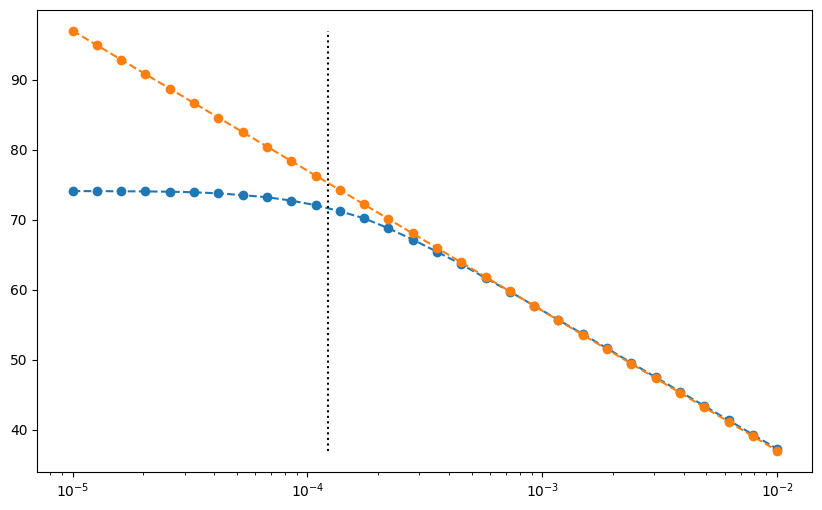

In [17]:
fig, ax = plt.subplots()

ax.plot(kTC_noise_rms, 20*np.log10(sndr), linestyle='dashed', 
       marker='o')

n = 12
vref = 1.0
vlsb = vref / (2 ** n)
vd_peak = vref-(vlsb/2)
vd_rms = vd_peak / np.sqrt(2)

eq_sndr_vin_kTC = 20*np.log10(vd_rms/kTC_noise_rms)
ax.plot(kTC_noise_rms, eq_sndr_vin_kTC, 
        linestyle='dashed', marker='o')

ax.vlines(x=vlsb/2, ymin=min(eq_sndr_vin_kTC), 
          ymax=max(eq_sndr_vin_kTC), linestyle='dotted', color='black')

ax.set_xscale('log')

### Comparator Input Noise

In [18]:
!python ./src/dynamic_sim.py -n 12 -N 16384 -M 511 -cn 1e-3 \
-o ./data/comp_noise_1mVrms_sim.csv > /dev/null

(np.float64(892.7129119368021), np.float64(25222.280844729536))

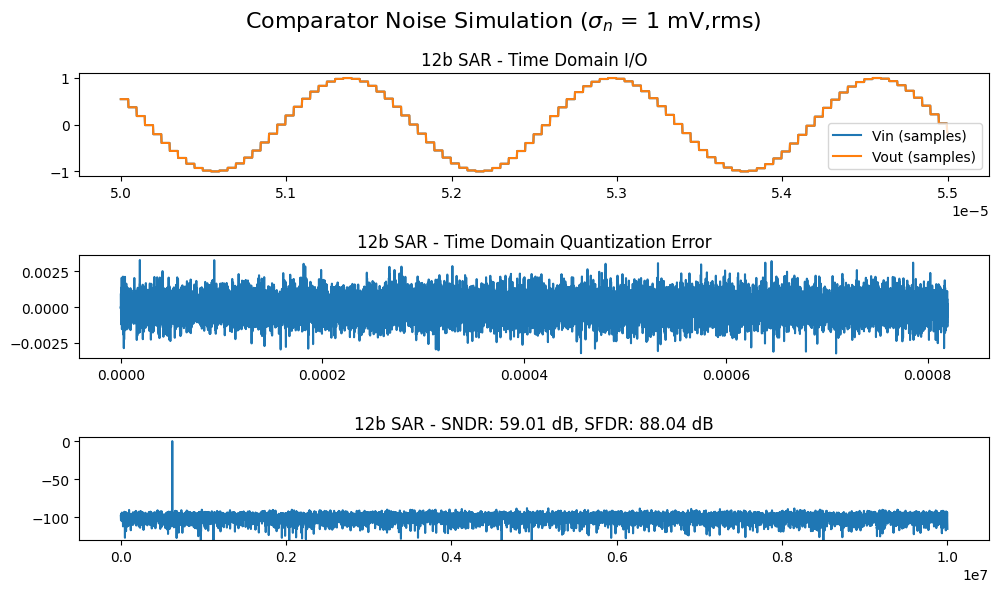

In [19]:
df = './data/comp_noise_1mVrms_sim.csv'
res = '12b'
n = 12
N = 16384
M = 511
f_clk = 20e6
td_tstart = 50e-6
td_tstop = 55e-6
fig_title = 'Comparator Noise Simulation ($\\sigma_{n}$ = 1 mV,rms)'
bulk_dynamic_sim_analysis(df, res, n, N, M, f_clk, td_tstart, td_tstop, fig_title)

In [20]:
comparator_noise_rms = np.logspace(start=-5, stop=-2, num=30)

N = 4096
M = 13
n = 12
f_clk = 20e6

sndr = np.zeros(comparator_noise_rms.shape)

for i, cn in enumerate(comparator_noise_rms):
    print(f'Comparator Noise: {cn} Vrms')
    subprocess.run([
        "python", "./src/dynamic_sim.py", 
        "-n", f"{n}",
        "-N", f"{N}",
        "-M", f"{M}",
        "-o", f"./data/comp_noise_sweep_{int(cn*1e9)}nVrms.csv",
        "-cn", str(cn)
    ], stdout=subprocess.DEVNULL)
    df = f"./data/comp_noise_sweep_{int(cn*1e9)}nVrms.csv"
    sndr[i], _ = bulk_dynamic_sim_analysis(df, '12b', 12, N, M, f_clk, plot_enable=False)

Comparator Noise: 1e-05 Vrms
Comparator Noise: 1.2689610031679234e-05 Vrms
Comparator Noise: 1.610262027560939e-05 Vrms
Comparator Noise: 2.0433597178569438e-05 Vrms
Comparator Noise: 2.592943797404667e-05 Vrms
Comparator Noise: 3.290344562312671e-05 Vrms
Comparator Noise: 4.1753189365604006e-05 Vrms
Comparator Noise: 5.2983169062837125e-05 Vrms
Comparator Noise: 6.723357536499335e-05 Vrms
Comparator Noise: 8.531678524172815e-05 Vrms
Comparator Noise: 0.00010826367338740541 Vrms
Comparator Noise: 0.00013738237958832637 Vrms
Comparator Noise: 0.00017433288221999874 Vrms
Comparator Noise: 0.000221221629107045 Vrms
Comparator Noise: 0.0002807216203941176 Vrms
Comparator Noise: 0.0003562247890262444 Vrms
Comparator Noise: 0.00045203536563602405 Vrms
Comparator Noise: 0.0005736152510448681 Vrms
Comparator Noise: 0.0007278953843983146 Vrms
Comparator Noise: 0.0009236708571873865 Vrms
Comparator Noise: 0.0011721022975334804 Vrms
Comparator Noise: 0.0014873521072935117 Vrms
Comparator Noise: 0

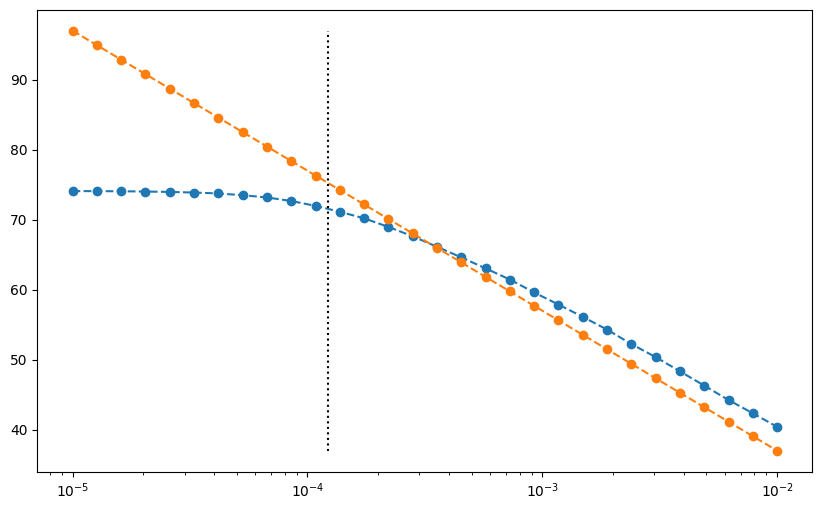

In [21]:
comparator_noise_rms = np.logspace(start=-5, stop=-2, num=30)
fig, ax = plt.subplots()

ax.plot(comparator_noise_rms, 20*np.log10(sndr), linestyle='dashed', 
       marker='o')

n = 12
vref = 1.0
vlsb = vref / (2 ** n)
vd_peak = vref-(vlsb/2)
vd_rms = vd_peak / np.sqrt(2)

eq_sndr_vin_comp = 20*np.log10(vd_rms/comparator_noise_rms)
ax.plot(comparator_noise_rms, eq_sndr_vin_comp, 
        linestyle='dashed', marker='o')

ax.vlines(x=vlsb/2, ymin=min(eq_sndr_vin_comp), 
          ymax=max(eq_sndr_vin_comp), linestyle='dotted', color='black')

ax.set_xscale('log')

* double check reference for model of this effect
* Show comparator input-referred noise PSD and analog conversion result PSD on same plot for converter limited by comparator noise 

### CDAC Settling Error

* Murmann review paper + paper that does the math
* Simulation to show effect of sub-radix 2 CDAC in mitigating settling error

In [22]:
!python ./src/single_conv_3b_sim.py -o ./data/single_conv_3b_se_10pct.csv -se 10 > /dev/null
!python ./src/single_conv_3b_sim.py -o ./data/single_conv_3b_se_25pct.csv -se 25 > /dev/null

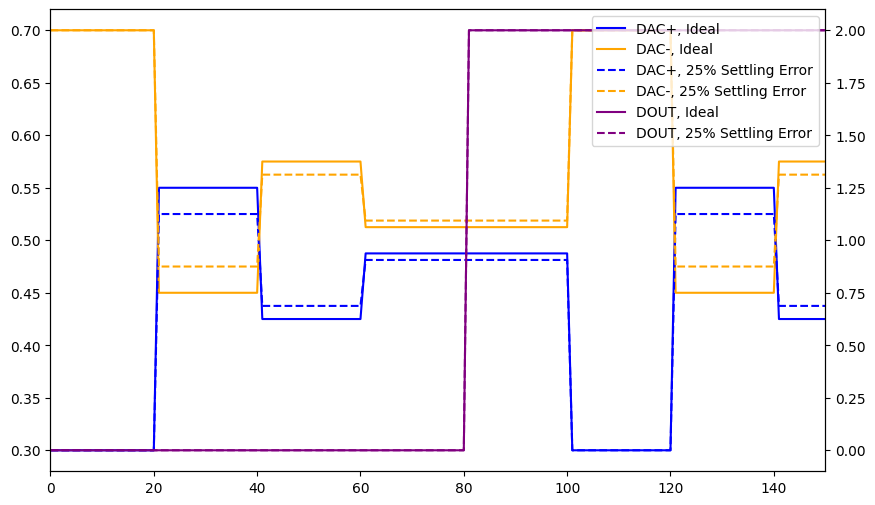

In [23]:
ideal_df = './data/single_conv_3b.csv'
se_df = './data/single_conv_3b_se_10pct.csv'

ideal_dataset = np.genfromtxt(ideal_df, delimiter=',', skip_header=1)
se_dataset = np.genfromtxt(se_df, delimiter=',', skip_header=1)

ideal_compp = ideal_dataset[:, 1]
ideal_compn = ideal_dataset[:, 2]
ideal_dout = ideal_dataset[:, 4]
se_compp = se_dataset[:, 1]
se_compn = se_dataset[:, 2]
se_dout = se_dataset[:, 4]

fig, ax = plt.subplots()

ax.plot(ideal_compp, color='blue', label='DAC+, Ideal')
ax.plot(ideal_compn, color='orange', label='DAC-, Ideal')
ax.plot(se_compp, linestyle='dashed', color='blue', label='DAC+, 25% Settling Error')
ax.plot(se_compn, linestyle='dashed', color='orange', label='DAC-, 25% Settling Error')

ax2 = ax.twinx()
ax2.plot(ideal_dout, color='purple', label='DOUT, Ideal')
ax2.plot(se_dout, color='purple', linestyle='dashed', label='DOUT, 25% Settling Error')

# Collect handles and labels from both axes
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax.set_xlim([0, 150])

# Create a single legend using combined handles and labels
ax2.legend(h1 + h2, l1 + l2, loc='upper right')

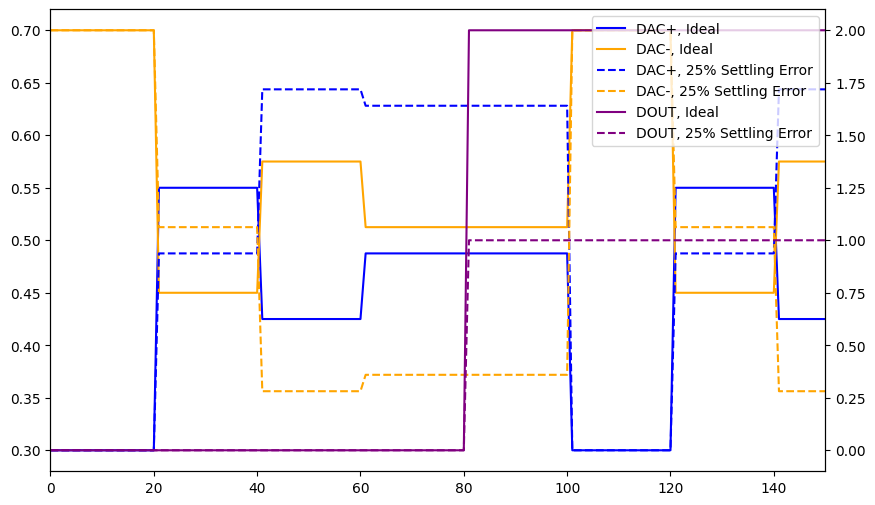

In [24]:
ideal_df = './data/single_conv_3b.csv'
se_df = './data/single_conv_3b_se_25pct.csv'

ideal_dataset = np.genfromtxt(ideal_df, delimiter=',', skip_header=1)
se_dataset = np.genfromtxt(se_df, delimiter=',', skip_header=1)

ideal_compp = ideal_dataset[:, 1]
ideal_compn = ideal_dataset[:, 2]
ideal_dout = ideal_dataset[:, 4]
se_compp = se_dataset[:, 1]
se_compn = se_dataset[:, 2]
se_dout = se_dataset[:, 4]

fig, ax = plt.subplots()

ax.plot(ideal_compp, color='blue', label='DAC+, Ideal')
ax.plot(ideal_compn, color='orange', label='DAC-, Ideal')
ax.plot(se_compp, linestyle='dashed', color='blue', label='DAC+, 25% Settling Error')
ax.plot(se_compn, linestyle='dashed', color='orange', label='DAC-, 25% Settling Error')

ax2 = ax.twinx()
ax2.plot(ideal_dout, color='purple', label='DOUT, Ideal')
ax2.plot(se_dout, color='purple', linestyle='dashed', label='DOUT, 25% Settling Error')

# Collect handles and labels from both axes
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax.set_xlim([0, 150])

# Create a single legend using combined handles and labels
ax2.legend(h1 + h2, l1 + l2, loc='upper right')

In [25]:
!python ./src/generate_weights.py -n 15 -r 1.86 -u 1e-14 -s 5e-15 -o ./config > /dev/null

In [26]:
fp = './config/weights_estimated_15b_radix1_86.npy'
print(fp)
print(np.load(fp))

./config/weights_estimated_15b_radix1_86.npy
[4.62407503e-01 2.48606184e-01 1.33659239e-01 7.18598058e-02
 3.86343042e-02 2.07711313e-02 1.11672749e-02 6.00391123e-03
 3.22790926e-03 1.73543509e-03 9.33029617e-04 5.01628826e-04
 2.69692917e-04 1.44996192e-04 7.79549420e-05]


In [27]:
settling_error_pct = np.arange(start=0, stop=21, step=2)

N = 4096
M = 13
n = 12
f_clk = 20e6

radix2_sfdr = np.zeros(settling_error_pct.shape)
subradix2_sfdr = np.zeros(settling_error_pct.shape)
radix2_sndr = np.zeros(settling_error_pct.shape)
subradix2_sndr = np.zeros(settling_error_pct.shape)
for i, se in enumerate(settling_error_pct):
    print(f'Settling Error: {se} percent')
    subprocess.run([
        "python", "./src/dynamic_sim.py", 
        "-n", f"{n}",
        "-N", f"{N}",
        "-M", f"{M}",
        "-o", f"./data/se_sim_r2_00_se_{se}_pct.csv",
        "-se", str(se)
    ], stdout=subprocess.DEVNULL)
    df = f"./data/se_sim_r2_00_se_{se}_pct.csv"
    radix2_sndr[i], radix2_sfdr[i] = bulk_dynamic_sim_analysis(df, '12b', 12, N, M, f_clk, plot_enable=False)

    subprocess.run([
        "python", "./src/dynamic_sim.py", 
        "-n", f"{n}",
        "-N", f"{N}",
        "-M", f"{M}",
        "-wa", "./config/weights_estimated_15b_radix1_86.npy",
        "-o", f"./data/se_sim_r1_86_se_{se}_pct.csv",
        "-se", str(se)
    ], stdout=subprocess.DEVNULL)

    df = f"./data/se_sim_r1_86_se_{se}_pct.csv"
    subradix2_sndr[i], subradix2_sfdr[i] = bulk_dynamic_sim_analysis(df, '12b', 12, N, M, f_clk, plot_enable=False)

Settling Error: 0 percent
Settling Error: 2 percent
Settling Error: 4 percent
Settling Error: 6 percent
Settling Error: 8 percent
Settling Error: 10 percent
Settling Error: 12 percent
Settling Error: 14 percent
Settling Error: 16 percent
Settling Error: 18 percent
Settling Error: 20 percent


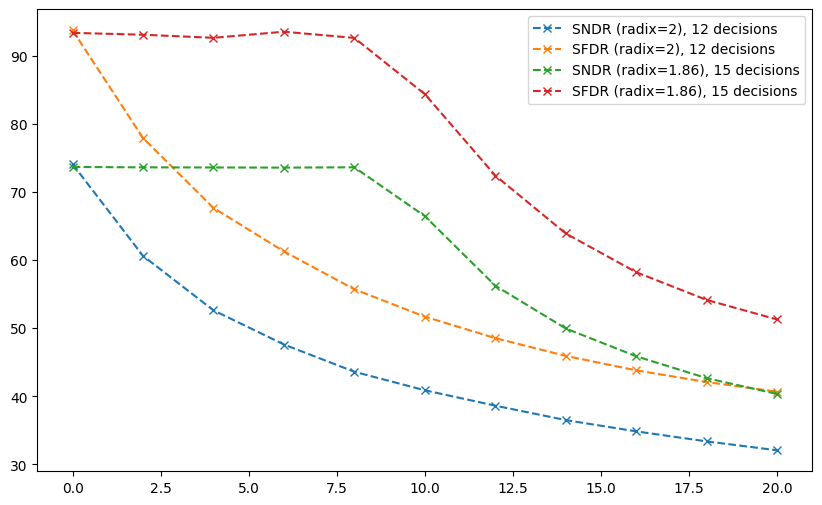

In [28]:
fig, ax = plt.subplots()
ax.plot(settling_error_pct, 20*np.log10(radix2_sndr), label='SNDR (radix=2), 12 decisions', marker='x', linestyle='dashed')
ax.plot(settling_error_pct, 20*np.log10(radix2_sfdr), label='SFDR (radix=2), 12 decisions', marker='x', linestyle='dashed')

ax.plot(settling_error_pct, 20*np.log10(subradix2_sndr), label='SNDR (radix=1.86), 15 decisions', marker='x', linestyle='dashed')
ax.plot(settling_error_pct, 20*np.log10(subradix2_sfdr), label='SFDR (radix=1.86), 15 decisions', marker='x', linestyle='dashed')
ax.legend()

## Prototyping SAR ADC Background Calibration Algorithms

### ADC Calibration Primer

* foreground vs. background calibration
* trade-offs between hardware complexity, analog vs. digital implementation, convergence speed, etc.

### Using PathSim to Prototype Offset Double Conversion (ODC) Background Calibration Scheme

* Chiu reference paper
* Basic simulation setup
* Double conversion time domain plot with no mismatch
    * Show mean of two outputs and difference
* Demo shows convergence with only capacitor mismatch considered
    * single block of data acquired with low-frequency input
    * weights updated after each block via batch gradient descent
    * block size and number of iterations fixed with learning rates mu1 and mu2
    * show learning curves (weight/offset MSE and SFDR/SNDR against batch #)

In [29]:
!python ./src/odc_ctrl_demo.py -a 5 -o ./data/odc_ctrl_offset5.csv > /dev/null
!python ./src/odc_ctrl_demo.py -a 10 -o ./data/odc_ctrl_offset10.csv > /dev/null

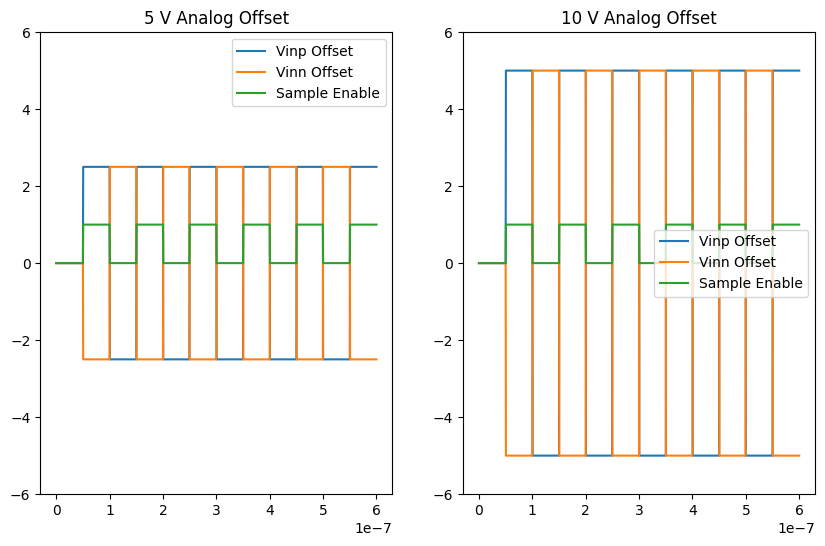

In [30]:
datafiles = ['./data/odc_ctrl_offset5.csv', './data/odc_ctrl_offset10.csv']
offset = ['5 V Analog Offset', '10 V Analog Offset']
fig, axs = plt.subplots(1, 2)

for i, df in enumerate(datafiles):
    
    dataset = np.genfromtxt(df, delimiter=',', skip_header=1)

    t = dataset[:, 0]
    vinp_offset = dataset[:, 1]
    vinn_offset = dataset[:, 2]
    samp_en = dataset[:, 3]
    odc_state = dataset[:, 4]

    axs[i].plot(t, vinp_offset, label='Vinp Offset')
    axs[i].plot(t, vinn_offset, label='Vinn Offset')
    axs[i].plot(t, samp_en, label='Sample Enable')
    axs[i].set_ylim([-6, 6])
    axs[i].set_title(offset[i])
    
    axs[i].legend()

In [31]:
!python ./src/crsar_cal_get_block.py -c ./config/crsar_cal_get_block_offset25lsb_ideal.toml > /dev/null
!python ./src/crsar_cal_get_block.py -c ./config/crsar_cal_get_block_offset25lsb_nonideal.toml > /dev/null

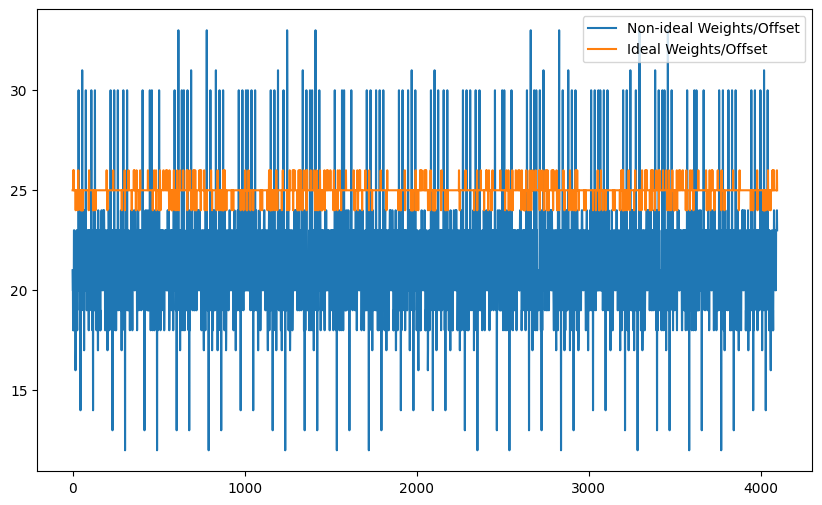

In [32]:
# manually compare ADC outputs for both cases
datafiles = ['./data/cal_offset25lsb_nonideal.npz', './data/cal_offset25lsb_ideal.npz']
labels = ['Non-ideal Weights/Offset', 'Ideal Weights/Offset']

fig, ax = plt.subplots()
for i, df in enumerate(datafiles):
    
    dataset = np.load(df)
    dout_offsetp = dataset["dout_offsetp"]
    dout_offsetn = dataset["dout_offsetn"]
    conv_diff = dout_offsetp - dout_offsetn

    ax.plot(conv_diff, label=labels[i])

    ax.legend()

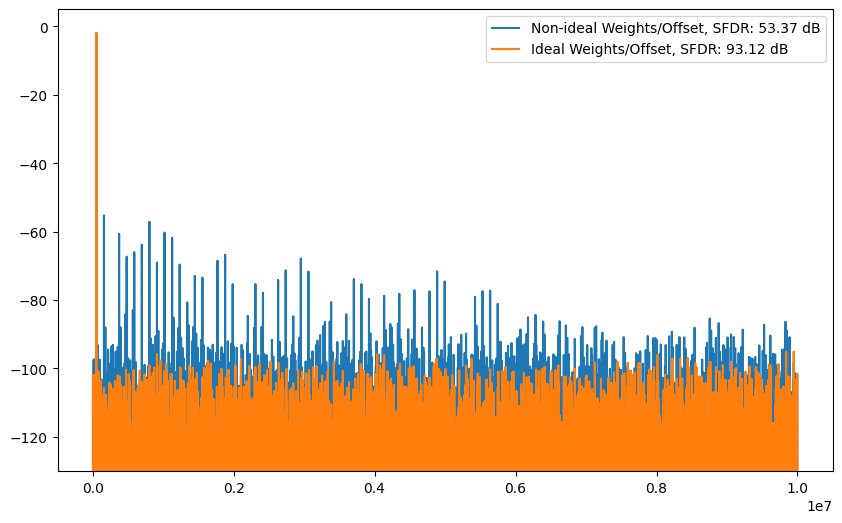

In [33]:
fig, ax = plt.subplots()
for i, df in enumerate(datafiles):
    
    dataset = np.load(df)
    dout_offsetp = dataset["dout_offsetp"]
    dout_offsetn = dataset["dout_offsetn"]
    conv_result = dout_offsetp*0.5 + dout_offsetn*0.5
    f, fft, sndr, sfdr = compute_dynamic_performance(conv_result, f_clk=20e6, N=4096, M=11)
    
    ax.plot(f, 20*np.log10(fft), label=f'{labels[i]}, SFDR: {20*np.log10(sfdr):.2f} dB')
    ax.set_ylim([-130, 5])
    ax.legend()


In [34]:
!python ./src/odc_train_demo.py \
-c ./config/crsar_cal_get_block_offset25lsb_nonideal.toml \
-d ./data/cal_offset25lsb_nonideal.npz \
-o ./data/cal_results_offset25lsb_nonideal.npz

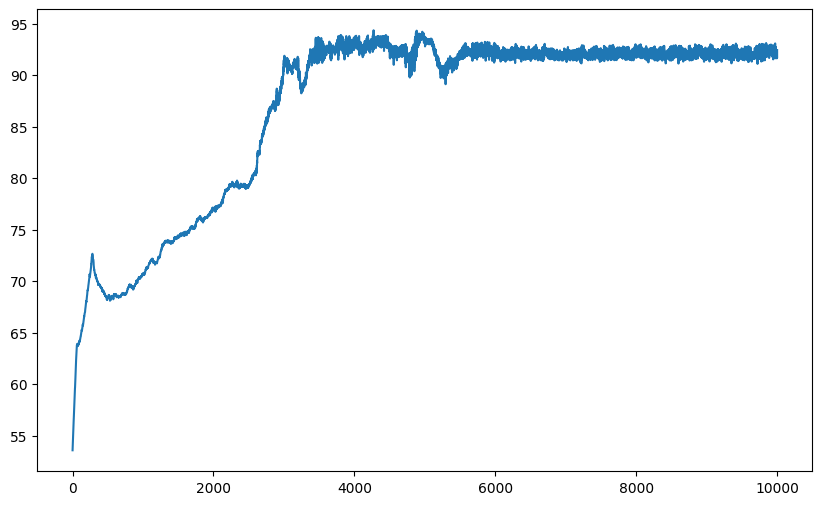

In [35]:
cal_results = np.load('./data/cal_results_offset25lsb_nonideal.npz')
fig, ax = plt.subplots()

ax.plot(20*np.log10(cal_results["sfdr_learning_curve"]))

(-130.0, 0.0)

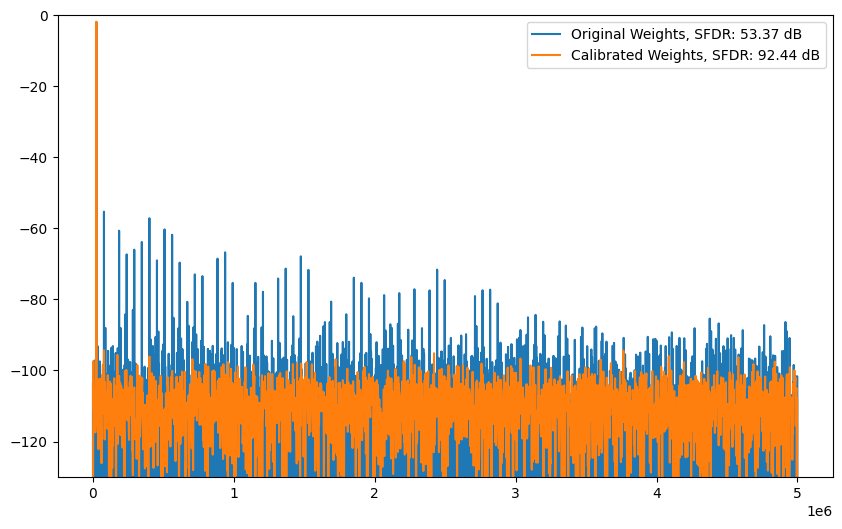

In [36]:
fig, ax = plt.subplots()

ax.plot(cal_results["fft_freq"], 20*np.log10(cal_results["fft_original"]), 
        label=f'Original Weights, SFDR: {20*np.log10(cal_results["sfdr_original"]):.2f} dB')
ax.plot(cal_results["fft_freq"], 20*np.log10(cal_results["fft_calibrated"]), 
        label=f'Calibrated Weights, SFDR: {20*np.log10(cal_results["sfdr_calibrated"]):.2f} dB')

ax.legend()
ax.set_ylim([-130, 0])

## Summary/Future Work

* get feedback from community on how to make SAR model better
    * would a standard interface actually be helpful?
* implementation of other calibration methods exploring trade-offs
    * e.g., how robust is method to input signal?  
* expand to implement models for more circuits
* auto-generation of circuit models from text-based specification
* exploration of browser-based PathView for rapid block-diagram modeling (would be especially helpful for documenting system simulation setups)

## References